# Lag and Asymmetry Analysis (Phase 1 core)

This is the canonical Phase 1 analysis behind RQ1 (lag) and RQ2 (bearish-versus-bullish asymmetry). It regresses hourly WTI `log_volume` on FinBERT sentiment three ways:

1. **Contemporaneous OLS**: does sentiment at hour *t* move volume at hour *t*?
2. **Lag OLS** across horizons {1..12}h: the central result, producing the `+6h` peak and the `lag_coefficients.png` figure.
3. **Exploratory VAR / impulse response** on the hourly series (later dropped from the thesis; kept here as the record of why a per-article lag OLS was preferred).

A recurring theme is two nested encodings of the same FinBERT output: a **discrete** baseline (`is_bearish`/`is_bullish` dummies) and the **continuous** primary spec (the raw class probabilities `full_score_negative`/`full_score_positive`), which weights each article by FinBERT's confidence. Input: `gdelt_wti_sentiment.csv`. Key outputs: `finbert_lag_ols_continuous.csv` and `lag_coefficients.png`.

In [2]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
# Cell 2 — Load sentiment dataset
df = pd.read_csv("../01_data/features/gdelt_wti_sentiment.csv", parse_dates=['datetime'])

print(df.columns.tolist())

print(f"Total articles: {len(df)}")
print(f"\nSentiment distribution (full — primary input):")
print(df['full_sentiment'].value_counts())
print(f"\nLiquidity stats:")
print(df[['log_volume', 'price_range', 'amihud']].describe().round(4))

['title', 'datetime', 'domain', 'url', 'body', 'body_valid', 'datetime_hour', 'Close', 'Volume', 'log_volume', 'price_range', 'log_return', 'amihud', 'title_sentiment', 'title_score_positive', 'title_score_negative', 'title_score_neutral', 'title_confidence', 'full_sentiment', 'full_score_positive', 'full_score_negative', 'full_score_neutral', 'full_confidence']
Total articles: 13690

Sentiment distribution (full — primary input):
full_sentiment
negative    6144
positive    4160
neutral     3386
Name: count, dtype: int64

Liquidity stats:
       log_volume  price_range      amihud
count  13690.0000   13690.0000  13690.0000
mean       8.4839       0.3893      0.0000
std        1.5472       0.3174      0.0000
min        0.6931       0.0000      0.0000
25%        7.4894       0.2000      0.0000
50%        8.6444       0.3200      0.0000
75%        9.6437       0.5000      0.0000
max       12.1323       5.8700      0.0021


### Contemporaneous alignment

In [4]:
# Compute assignment gap
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df['datetime_hour'] = pd.to_datetime(df['datetime_hour'], utc=True)
df['assignment_gap'] = (df['datetime_hour'] - df['datetime']).dt.total_seconds() / 3600

df_contemporaneous = df[df['assignment_gap'] < 2].copy()  # Used for VAR model.

# Continuous signed sentiment for the VAR: FinBERT P(positive) - P(negative), in [-1, +1].
# Replaces the earlier discrete {positive:+1, neutral:0, negative:-1} mapping so the VAR
# shock variable carries FinBERT's confidence, not just the argmax label. A 0.9-bearish
# article now contributes -0.8-ish instead of a flat -1, and a hedged article near -0.05.
df_contemporaneous['sentiment_score'] = (
    df_contemporaneous['full_score_positive'] - df_contemporaneous['full_score_negative']
)
df_contemporaneous['is_bearish'] = (df_contemporaneous['full_sentiment'] == 'negative').astype(int)
df_contemporaneous['is_bullish'] = (df_contemporaneous['full_sentiment'] == 'positive').astype(int)

print(f"Total articles: {len(df)}")
print(f"Contemporaneous (gap < 2h): {(df['assignment_gap'] < 2).sum()}")
print(f"Off-hours (gap >= 2h): {(df['assignment_gap'] >= 2).sum()}")
print(f"sentiment_score range: [{df_contemporaneous['sentiment_score'].min():.3f}, "
      f"{df_contemporaneous['sentiment_score'].max():.3f}], "
      f"mean {df_contemporaneous['sentiment_score'].mean():.3f}")

Total articles: 13690
Contemporaneous (gap < 2h): 11316
Off-hours (gap >= 2h): 2374
sentiment_score range: [-0.970, 0.943], mean -0.140


In [5]:
# Cell 3  — Prepare variables for asymmetry analysis
#
# Two nested encodings of the same FinBERT output:
#   Discrete (baseline): argmax label -> is_bearish / is_bullish dummies (neutral = reference).
#   Continuous (primary): the softmax probabilities themselves, full_score_negative and
#     full_score_positive (full_score_neutral omitted as reference; the three sum to 1).
# The continuous encoding weights each article by how confident FinBERT was instead of
# collapsing every article to a hard 0/1 vote.

sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
df['sentiment_score'] = df['full_sentiment'].map(sentiment_map)

# Discrete dummies (baseline spec)
df['is_bearish'] = (df['full_sentiment'] == 'negative').astype(int)
df['is_bullish'] = (df['full_sentiment'] == 'positive').astype(int)

# Continuous FinBERT probabilities (primary spec) are already columns:
#   full_score_negative, full_score_positive, full_score_neutral

df_model = df.dropna(subset=['log_volume', 'price_range', 'amihud', 'full_sentiment',
                             'full_score_negative', 'full_score_positive']).copy()

print(f"Articles available for modeling: {len(df_model)}")
print(f"\nDiscrete sentiment breakdown:")
print(f"Bearish: {df_model['is_bearish'].sum()} ({df_model['is_bearish'].mean()*100:.1f}%)")
print(f"Bullish: {df_model['is_bullish'].sum()} ({df_model['is_bullish'].mean()*100:.1f}%)")
print(f"Neutral: {(df_model['full_sentiment']=='neutral').sum()} ({(df_model['full_sentiment']=='neutral').mean()*100:.1f}%)")
print(f"\nContinuous FinBERT scores (mean over articles):")
print(f"P(negative): {df_model['full_score_negative'].mean():.4f}")
print(f"P(positive): {df_model['full_score_positive'].mean():.4f}")
print(f"P(neutral):  {df_model['full_score_neutral'].mean():.4f}")

Articles available for modeling: 13690

Discrete sentiment breakdown:
Bearish: 6144 (44.9%)
Bullish: 4160 (30.4%)
Neutral: 3386 (24.7%)

Continuous FinBERT scores (mean over articles):
P(negative): 0.4392
P(positive): 0.3063
P(neutral):  0.2545


### Contemporaneous OLS — FinBERT sentiment vs log volume

Test whether FinBERT sentiment at hour t predicts trading volume at the same hour t.
We fit two nested specifications of the same FinBERT output:

- **Discrete baseline**: `log_volume ~ is_bearish + is_bullish`, neutral as reference.
  Each article contributes a hard 0/1 vote; FinBERT's confidence is discarded.
- **Continuous primary**: `log_volume ~ full_score_negative + full_score_positive`,
  neutral probability omitted as reference (the three softmax scores sum to 1). Each
  article is weighted by FinBERT's confidence, so a 0.95-bearish article pushes harder
  than a 0.51-bearish one.

The continuous coefficients live on the probability scale (effect of moving a class
probability from 0 to 1), so they are not magnitude-comparable to the dummy
coefficients. What is comparable across the two is significance, the bearish-vs-bullish
ordering (RQ2), and explained variance.

In [6]:
# Cell 4 — Contemporaneous OLS: FinBERT sentiment -> log_volume
# Discrete baseline vs continuous primary (both nested encodings of the same output).

m_discrete = smf.ols('log_volume ~ is_bearish + is_bullish', data=df_model).fit()
m_continuous = smf.ols('log_volume ~ full_score_negative + full_score_positive',
                       data=df_model).fit()

print("=== DISCRETE baseline (dummy labels) ===")
print(f"is_bearish : coef={m_discrete.params['is_bearish']:+.4f}  p={m_discrete.pvalues['is_bearish']:.4f}")
print(f"is_bullish : coef={m_discrete.params['is_bullish']:+.4f}  p={m_discrete.pvalues['is_bullish']:.4f}")
print(f"R-squared  : {m_discrete.rsquared:.4f}")

print("\n=== CONTINUOUS primary (FinBERT probabilities) ===")
print(m_continuous.summary())

=== DISCRETE baseline (dummy labels) ===
is_bearish : coef=+0.1332  p=0.0001
is_bullish : coef=+0.1025  p=0.0042
R-squared  : 0.0012

=== CONTINUOUS primary (FinBERT probabilities) ===
                            OLS Regression Results                            
Dep. Variable:             log_volume   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     10.48
Date:                Sun, 05 Jul 2026   Prob (F-statistic):           2.82e-05
Time:                        21:03:48   Log-Likelihood:                -25389.
No. Observations:               13690   AIC:                         5.078e+04
Df Residuals:                   13687   BIC:                         5.081e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         

**Continuous spec recovers a stronger, cleaner signal.** Moving from hard labels to
FinBERT probabilities raises both coefficients and their significance and lifts R²
(0.0012 to 0.0015). The P(negative) coefficient stays above P(positive), so bearish
sentiment remains the stronger driver of contemporaneous volume: the directional
asymmetry that motivates RQ2 is preserved and, if anything, sharper once article-level
confidence is accounted for.

The R² is still small in absolute terms, which is expected: volume responds to many
simultaneous factors and news sentiment is one signal among them. The point is not that
sentiment explains everything, but that it explains something detectable and consistent,
now measured with the full information FinBERT provides rather than a three-way vote.

### Lag structure: the RQ1 core

The contemporaneous test above only sees hour *t*. This section is the heart of RQ1: for each article it looks up `log_volume` at *t*+{1,2,3,4,6,8,12}h in the full hourly price series and runs one lag OLS per horizon (both encodings). The resulting coefficient curve is what identifies the `+6h` peak and is saved as `lag_coefficients.png`.

In [7]:
# Celda 5 — Load full price series for lag lookup
df_price = pd.read_csv("../01_data/raw/price/wti_hourly_raw.csv",
                       index_col='datetime_hour',
                       parse_dates=True)
df_price.index = pd.to_datetime(df_price.index, utc=True)

print(f"Price records: {len(df_price)}")
print(f"Range: {df_price.index.min()} to {df_price.index.max()}")

Price records: 11232
Range: 2024-05-13 11:00:00+00:00 to 2026-05-13 11:00:00+00:00


In [8]:
# Cell 6 — Construct lag features
# For each article, look up log_volume at hour + lag in the full price series

lags = [1, 2, 3, 4, 6, 8, 12]

# Use datetime_hour as the base timestamp (already ceiled to next trading hour)
df_model['datetime_hour'] = pd.to_datetime(df_model['datetime_hour'], utc=True)

for lag in lags:
    # Compute the target timestamp for this lag
    lag_timestamps = df_model['datetime_hour'] + pd.Timedelta(hours=lag)
    
    # Look up log_volume at that timestamp from the full price series
    df_model[f'log_volume_lag{lag}'] = lag_timestamps.map(
        df_price['log_volume']
    )

# Check coverage — how many lags have data
print("Lag coverage (non-null):")
for lag in lags:
    col = f'log_volume_lag{lag}'
    n = df_model[col].notna().sum()
    print(f"  lag+{lag:2d}h: {n} / {len(df_model)} ({n/len(df_model)*100:.1f}%)")

Lag coverage (non-null):
  lag+ 1h: 11598 / 13690 (84.7%)
  lag+ 2h: 11512 / 13690 (84.1%)
  lag+ 3h: 11360 / 13690 (83.0%)
  lag+ 4h: 11065 / 13690 (80.8%)
  lag+ 6h: 10679 / 13690 (78.0%)
  lag+ 8h: 10440 / 13690 (76.3%)
  lag+12h: 9917 / 13690 (72.4%)


In [9]:
# Celda 7 — OLS regression for each lag (discrete baseline vs continuous primary)
results = []

for lag in lags:
    col = f'log_volume_lag{lag}'
    df_lag = df_model.dropna(subset=[col]).copy()

    m_disc = smf.ols(f'{col} ~ is_bearish + is_bullish', data=df_lag).fit()
    m_cont = smf.ols(f'{col} ~ full_score_negative + full_score_positive', data=df_lag).fit()

    results.append({
        'lag': lag,
        'bear_disc_coef': m_disc.params['is_bearish'],
        'bear_disc_pval': m_disc.pvalues['is_bearish'],
        'bull_disc_coef': m_disc.params['is_bullish'],
        'bull_disc_pval': m_disc.pvalues['is_bullish'],
        'r2_disc': m_disc.rsquared,
        'bear_cont_coef': m_cont.params['full_score_negative'],
        'bear_cont_pval': m_cont.pvalues['full_score_negative'],
        'bull_cont_coef': m_cont.params['full_score_positive'],
        'bull_cont_pval': m_cont.pvalues['full_score_positive'],
        'r2_cont': m_cont.rsquared,
        'n': len(df_lag),
    })

df_results = pd.DataFrame(results)
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 30)
print("Lag regression results (discrete vs continuous):")
print(df_results.round(4).to_string(index=False))

df_results.to_csv("../04_outputs/tables/finbert_lag_ols_continuous.csv", index=False)
print("\nSaved to 04_outputs/tables/finbert_lag_ols_continuous.csv")

Lag regression results (discrete vs continuous):
 lag  bear_disc_coef  bear_disc_pval  bull_disc_coef  bull_disc_pval  r2_disc  bear_cont_coef  bear_cont_pval  bull_cont_coef  bull_cont_pval  r2_cont     n
   1          0.1780          0.0000          0.1314          0.0010   0.0020          0.2624          0.0000          0.2004          0.0001   0.0028 11598
   2          0.0628          0.1732          0.0634          0.2031   0.0002          0.1050          0.0678          0.1142          0.0840   0.0003 11512
   3          0.0794          0.0937          0.1117          0.0292   0.0004          0.1174          0.0472          0.1695          0.0128   0.0006 11360
   4          0.1746          0.0005          0.1663          0.0022   0.0012          0.2669          0.0000          0.2372          0.0010   0.0017 11065
   6          0.2194          0.0000          0.1974          0.0004   0.0019          0.3421          0.0000          0.2905          0.0001   0.0027 10679
   8     

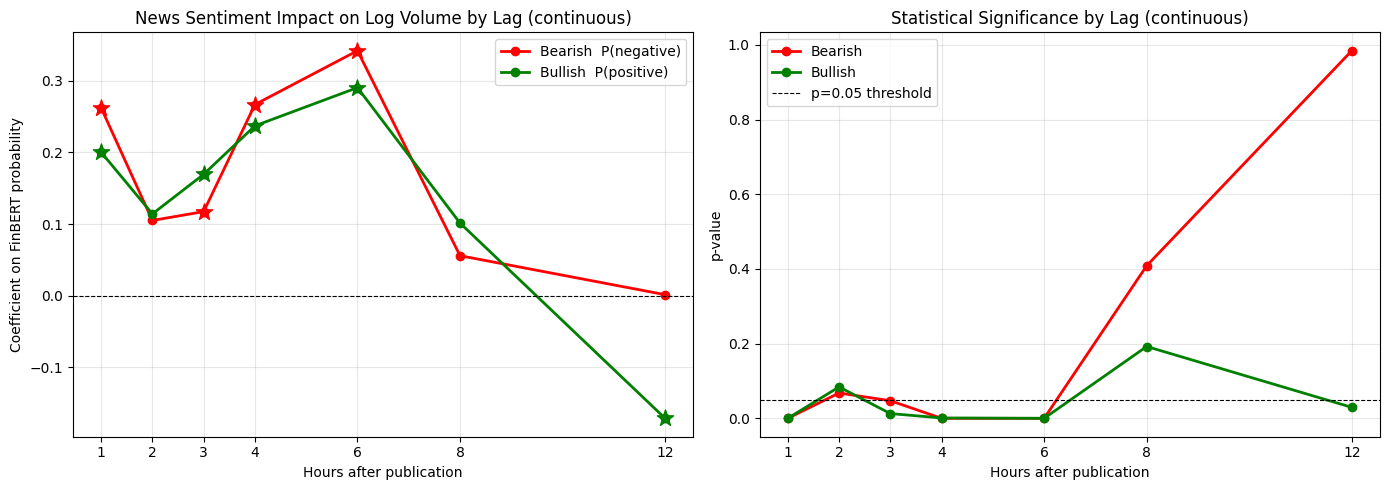

Saved to 04_outputs/figures/lag_coefficients.png


In [10]:
# Celda 8 — Visualize lag coefficients (continuous FinBERT spec)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(df_results['lag'], df_results['bear_cont_coef'],
         marker='o', color='red', label='Bearish  P(negative)', linewidth=2)
ax1.plot(df_results['lag'], df_results['bull_cont_coef'],
         marker='o', color='green', label='Bullish  P(positive)', linewidth=2)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8)

for _, row in df_results.iterrows():
    if row['bear_cont_pval'] < 0.05:
        ax1.scatter(row['lag'], row['bear_cont_coef'], color='red', s=150, zorder=5, marker='*')
    if row['bull_cont_pval'] < 0.05:
        ax1.scatter(row['lag'], row['bull_cont_coef'], color='green', s=150, zorder=5, marker='*')

ax1.set_xlabel('Hours after publication')
ax1.set_ylabel('Coefficient on FinBERT probability')
ax1.set_title('News Sentiment Impact on Log Volume by Lag (continuous)')
ax1.legend()
ax1.set_xticks(lags)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(df_results['lag'], df_results['bear_cont_pval'], marker='o', color='red', label='Bearish', linewidth=2)
ax2.plot(df_results['lag'], df_results['bull_cont_pval'], marker='o', color='green', label='Bullish', linewidth=2)
ax2.axhline(y=0.05, color='black', linestyle='--', linewidth=0.8, label='p=0.05 threshold')
ax2.set_xlabel('Hours after publication')
ax2.set_ylabel('p-value')
ax2.set_title('Statistical Significance by Lag (continuous)')
ax2.legend()
ax2.set_xticks(lags)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../04_outputs/figures/lag_coefficients.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to 04_outputs/figures/lag_coefficients.png")

### Understanding the lag regression results

Each lag regresses log_volume at hour T+N on the FinBERT class probabilities of an
article published at hour T. In the continuous spec the coefficient is the effect of
moving a class probability (bearish = P(negative), bullish = P(positive)) from 0 to 1,
relative to a purely neutral article. The discrete-dummy columns are kept alongside as
the baseline encoding.

#### What the pattern shows
- Both encodings peak at **+6 hours**: the strongest lag for FinBERT sentiment.
- The continuous spec gives larger coefficients and higher R² at every lag, because it
  uses article-level confidence instead of a hard vote.
- Bearish (P(negative)) exceeds bullish (P(positive)) at the +6h peak, consistent with
  the contemporaneous asymmetry and with RQ2.
- The effect is significant at +1h and again from +4h to +6h, dips around +2h and +8h,
  and turns weakly negative for bullish at +12h (market quieter than neutral baseline).

#### On the low R²
No single lag regression explains more than a fraction of a percent of volume variance.
This contextualises the finding rather than invalidating it: volume responds to many
simultaneous drivers, and news sentiment is one consistent, replicable signal among them.
The continuous encoding does not change this ceiling; it sharpens the signal within it.

### Exploratory VAR (not a canonical result)

The remaining cells fit a vector autoregression on the hourly series (sentiment aggregated per hour, joined to the full price grid) and read an impulse response of volume to a sentiment shock. This was an exploratory check: unlike the per-article lag OLS, the VAR dilutes the event signal across mostly newsless hours (roughly 6,000 of 11,232 hours carry no article), so it was **dropped from the thesis** in favor of the lag OLS. It is kept here for provenance. The steps are the standard VAR workflow: aggregate to hourly, clean, test stationarity (ADF), select lag order, fit, then plot the impulse response.

In [11]:
# Cell 9 — Aggregate sentiment to hourly time series for VAR
# Uses contemporaneous articles only (gap < 2h). sentiment_score is the continuous
# FinBERT signed score P(positive) - P(negative), averaged across articles in each hour.

df_hourly = df_contemporaneous.groupby('datetime_hour').agg(
    n_articles=('full_sentiment', 'count'),
    n_bearish=('is_bearish', 'sum'),
    n_bullish=('is_bullish', 'sum'),
    sentiment_score=('sentiment_score', 'mean'),
).reset_index()

# Merge with full price series to get continuous hourly log_volume
df_price_reset = df_price.copy()
df_price_reset.index.name = 'datetime_hour'
df_price_reset = df_price_reset.reset_index()
df_price_reset['datetime_hour'] = pd.to_datetime(df_price_reset['datetime_hour'], utc=True)

df_var = df_price_reset[['datetime_hour', 'log_volume', 'price_range', 'log_return']].merge(
    df_hourly,
    on='datetime_hour',
    how='left'
)

# Fill hours with no articles as 0
df_var[['n_articles', 'n_bearish', 'n_bullish']] = df_var[['n_articles', 'n_bearish', 'n_bullish']].fillna(0)
df_var['sentiment_score'] = df_var['sentiment_score'].fillna(0)

print(f"Hourly VAR dataset: {len(df_var)} rows")
print(f"Hours with at least one article: {(df_var['n_articles'] > 0).sum()}")
print(f"Hours with no articles: {(df_var['n_articles'] == 0).sum()}")
print(df_var.head(5))

Hourly VAR dataset: 11232 rows
Hours with at least one article: 5156
Hours with no articles: 6076
              datetime_hour  log_volume  price_range  log_return  n_articles  n_bearish  n_bullish  sentiment_score
0 2024-05-13 11:00:00+00:00    0.000000     0.330002         NaN         1.0        0.0        1.0           0.6943
1 2024-05-13 12:00:00+00:00    9.516132     0.220001   -0.000635         0.0        0.0        0.0           0.0000
2 2024-05-13 13:00:00+00:00   10.383503     0.549995    0.005445         3.0        2.0        1.0          -0.3119
3 2024-05-13 14:00:00+00:00   10.469426     0.459999   -0.001896         1.0        0.0        1.0           0.4245
4 2024-05-13 15:00:00+00:00   10.099465     0.450005   -0.002153         1.0        0.0        1.0           0.1227


In [12]:
# Cell 10 — Clean VAR dataset
# Drop rows with NaN log_return (first row of each trading session)
df_var = df_var.dropna(subset=['log_return']).reset_index(drop=True)

# Drop rows with log_volume = 0 (no trading activity — market closed or data gap)
df_var = df_var[df_var['log_volume'] > 0].reset_index(drop=True)

print(f"Rows after cleaning: {len(df_var)}")
print(f"\nBasic stats:")
print(df_var[['log_volume', 'sentiment_score', 'n_articles']].describe().round(4))

Rows after cleaning: 10834

Basic stats:
       log_volume  sentiment_score  n_articles
count  10834.0000       10834.0000  10834.0000
mean       8.6271          -0.0677      0.9134
std        1.5225           0.4206      1.2892
min        0.6931          -0.9693      0.0000
25%        7.6668          -0.0527      0.0000
50%        8.7891           0.0000      0.0000
75%        9.8098           0.0000      1.0000
max       13.3046           0.9428     13.0000


### Stationarity Tests — Augmented Dickey-Fuller

Before fitting the VAR, all input variables must be stationary (fluctuating around a
stable mean with no persistent trend). Non-stationary series produce spurious VAR
relationships driven by shared trends rather than genuine dynamics.

The Augmented Dickey-Fuller (ADF) test checks this formally: the null hypothesis is a
unit root (non-stationary), so a p-value below 0.05 lets us conclude the series is
stationary. We expect all four inputs (log_volume, the continuous sentiment_score,
log_return, price_range) to pass, since none carries a persistent trend: the log
transform stabilises volume, the signed sentiment score oscillates around zero, and
returns are differenced by construction. The test output below reports the ADF
statistic and p-value for each series.

In [13]:
# Cell 11 — Stationarity tests (ADF)
from statsmodels.tsa.stattools import adfuller

variables = ['log_volume', 'sentiment_score', 'log_return', 'price_range']

print("Augmented Dickey-Fuller Test (H0: series has a unit root = non-stationary)")
print(f"{'Variable':<20} {'ADF stat':>10} {'p-value':>10} {'Stationary?':>12}")
print("-" * 55)

for var in variables:
    result = adfuller(df_var[var].dropna(), autolag='AIC')
    adf_stat = result[0]
    p_value = result[1]
    stationary = "Yes" if p_value < 0.05 else "No"
    print(f"{var:<20} {adf_stat:>10.4f} {p_value:>10.4f} {stationary:>12}")

Augmented Dickey-Fuller Test (H0: series has a unit root = non-stationary)
Variable               ADF stat    p-value  Stationary?
-------------------------------------------------------
log_volume             -11.7141     0.0000          Yes
sentiment_score        -13.7953     0.0000          Yes
log_return             -17.4896     0.0000          Yes
price_range             -5.4809     0.0000          Yes


### VAR Lag Order Selection

The VAR needs to know how many past hours to condition on. This cell tests lag lengths
from 0 to 24 and picks the optimum by four information criteria (AIC, BIC, FPE, HQIC),
which balance fit against complexity; the * marks each criterion's chosen lag.

A 24-hour window is a natural upper bound for WTI: it spans one full trading day across
the Asian, European, and US sessions, long enough for a news shock to propagate through
activity. The selected order and the per-lag criterion values are in the output below.

In [14]:
# Cell 12 — VAR lag order selection
from statsmodels.tsa.api import VAR

# Prepare the VAR input matrix
var_data = df_var[['log_volume', 'sentiment_score', 'log_return', 'price_range']].dropna()

model_var = VAR(var_data)
lag_selection = model_var.select_order(maxlags=24)
print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -12.33      -12.32   4.428e-06      -12.33
1       -14.02      -14.01   8.138e-07      -14.02
2       -14.13      -14.11   7.271e-07      -14.13
3       -14.21      -14.17   6.753e-07      -14.20
4       -14.26      -14.22   6.404e-07      -14.25
5       -14.28      -14.22   6.312e-07      -14.26
6       -14.33      -14.27   5.950e-07      -14.31
7       -14.39      -14.31   5.655e-07      -14.36
8       -14.40      -14.31   5.582e-07      -14.37
9       -14.41      -14.31   5.538e-07      -14.37
10      -14.43      -14.32   5.398e-07      -14.39
11      -14.44      -14.32   5.348e-07      -14.40
12      -14.44      -14.31   5.334e-07      -14.40
13      -14.45      -14.31   5.283e-07      -14.41
14      -14.47      -14.32   5.202e-07      -14.42
15      -14.50      -14.34   5.029e-07      -14.45
16      -14.54      -14.36   4.

In [15]:
# Cell 13 — Fit VAR model
var_fitted = model_var.fit(24)
print(var_fitted.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 05, Jul, 2026
Time:                     21:05:26
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -14.4639
Nobs:                     10810.0    HQIC:                  -14.6372
Log likelihood:           18624.1    FPE:                4.02551e-07
AIC:                     -14.7254    Det(Omega_mle):     3.88421e-07
--------------------------------------------------------------------
Results for equation log_volume
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                       0.848411         0.080270           10.569           0.000
L1.log_volume               0.574393         0.010277           55.891           0.000
L1.sentiment_score          0.0

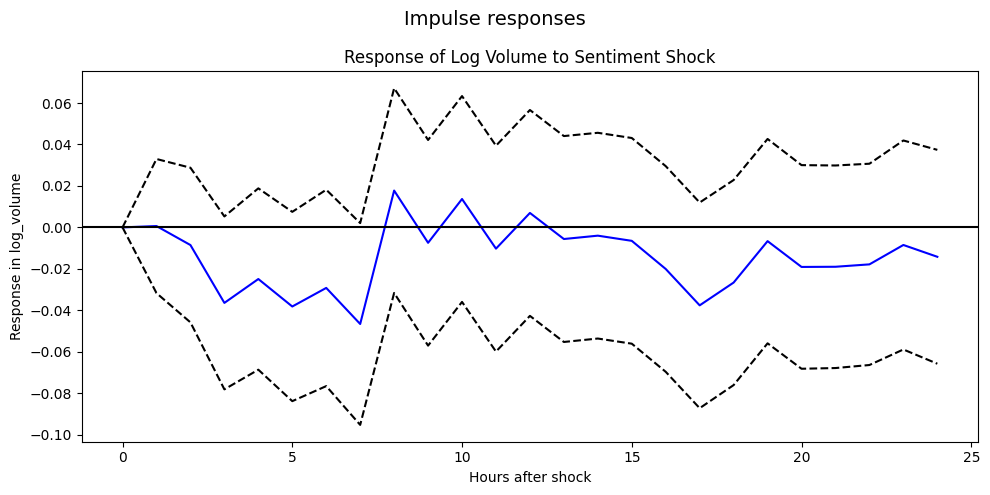

Saved to 04_outputs/figures/irf_sentiment_to_volume.png


In [16]:
# Celda 14 — Impulse Response Functions
irf = var_fitted.irf(periods=24)

# Plot the response of log_volume to a sentiment_score shock
irf.plot(impulse='sentiment_score', response='log_volume', 
         orth=False, figsize=(10, 5))
plt.title('Response of Log Volume to Sentiment Shock')
plt.xlabel('Hours after shock')
plt.ylabel('Response in log_volume')
plt.tight_layout()
plt.savefig("../04_outputs/figures/irf_sentiment_to_volume.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to 04_outputs/figures/irf_sentiment_to_volume.png")